In [1]:
import pandas as pd

# Load the process frequencies file
df = pd.read_csv("results/process_frequencies.csv")
verbs = df['process'].dropna().unique().tolist()

In [2]:
import spacy
nlp = spacy.load("en_core_web_md")

# Get vector for each verb
verb_vectors = [nlp(verb).vector for verb in verbs]

In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(verb_vectors)

# Attach cluster labels to verbs
clustered_verbs = pd.DataFrame({'verb': verbs, 'cluster': labels})

In [4]:
nova_anchors = {
    "NOVA 1": ["boil", "wash", "peel", "freeze"],
    "NOVA 2": ["press", "refine", "ferment"],
    "NOVA 3": ["bake", "can", "smoke", "add"],
    "NOVA 4": ["emulsify", "preserve", "flavor", "reconstitute"]
}

In [6]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Compute centroid vectors
centroids = kmeans.cluster_centers_

# Compare each centroid to anchor groups
def get_nova_label(centroid):
    scores = {}
    for nova_class, anchors in nova_anchors.items():
        anchor_vecs = [nlp(anchor).vector for anchor in anchors]
        sim = cosine_similarity([centroid], anchor_vecs).mean()
        scores[nova_class] = sim
    return max(scores, key=scores.get)

# Assign NOVA class to each cluster
cluster_to_nova = {i: get_nova_label(centroids[i]) for i in range(4)}
clustered_verbs['nova_class'] = clustered_verbs['cluster'].map(cluster_to_nova)

In [8]:
clustered_verbs.rename(columns={'verb': 'process'}, inplace=True)
final_df = clustered_verbs.merge(df, on='process')

In [9]:
# Merge with original frequencies
final_df = clustered_verbs.merge(df, on='process')
final_df.to_csv("results/classified_processes.csv", index=False)

In [10]:
from sklearn.decomposition import PCA

# Reduce 300D spaCy vectors to 2D for plotting
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(verb_vectors)

In [11]:
import numpy as np

# Add PCA coordinates to your DataFrame
clustered_verbs['x'] = reduced_vectors[:, 0]
clustered_verbs['y'] = reduced_vectors[:, 1]

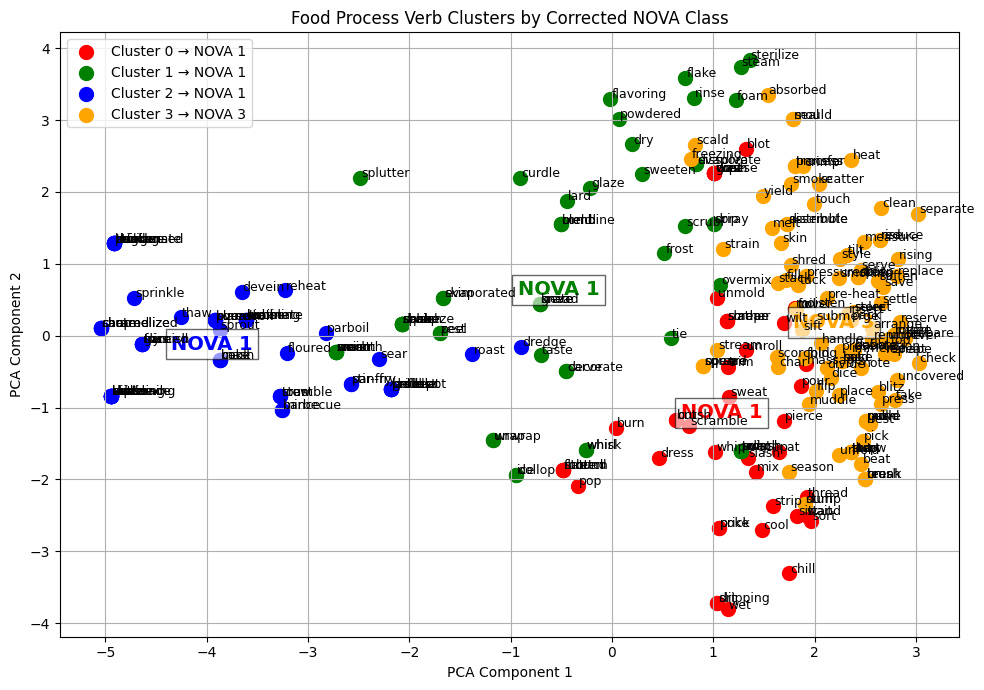

In [16]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce dimensions
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(verb_vectors)

# Add PCA coordinates to DataFrame
clustered_verbs['x'] = reduced_vectors[:, 0]
clustered_verbs['y'] = reduced_vectors[:, 1]

# Plot clusters with corrected NOVA labels
plt.figure(figsize=(10, 7))
colors = ['red', 'green', 'blue', 'orange']

for i in range(4):
    subset = clustered_verbs[clustered_verbs['cluster'] == i]
    plt.scatter(subset['x'], subset['y'], 
                color=colors[i], label=f"Cluster {i} → {cluster_to_nova[i]}", s=100)

    # Annotate cluster center with NOVA label
    center_x = subset['x'].mean()
    center_y = subset['y'].mean()
    plt.text(center_x, center_y, cluster_to_nova[i], fontsize=14, fontweight='bold',
             color=colors[i], ha='center', va='center', bbox=dict(facecolor='white', alpha=0.6))

# Annotate each verb (optional)
for _, row in clustered_verbs.iterrows():
    plt.text(row['x'] + 0.01, row['y'] + 0.01, row['process'], fontsize=9)

plt.title("Food Process Verb Clusters by Corrected NOVA Class")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
for i in range(4):
    print(f"\nCluster {i} → {cluster_to_nova[i]}")
    print(clustered_verbs[clustered_verbs['cluster'] == i]['process'].tolist())


Cluster 0 → NOVA 1
['mix', 'cool', 'cut', 'pour', 'coat', 'brush', 'grease', 'chill', 'stand', 'wash', 'dust', 'pat', 'scrape', 'trim', 'whip', 'thread', 'wipe', 'rub', 'flatten', 'prick', 'burn', 'pop', 'pierce', 'moisten', 'poke', 'wet', 'mound', 'wait', 'sit', 'unroll', 'sweat', 'scramble', 'unmold', 'dress', 'smear', 'slit', 'dripping', 'stretch', 'sort', 'strip', 'slash', 'blot', 'massage', 'wilt', 'slather']

Cluster 1 → NOVA 1
['combine', 'drain', 'whisk', 'smooth', 'blend', 'dry', 'cream', 'taste', 'peel', 'roll', 'knead', 'rinse', 'spray', 'wrap', 'soak', 'scoop', 'dissolve', 'shake', 'evaporated', 'steam', 'squeeze', 'grate', 'punch', 'warm', 'skim', 'decorate', 'zest', 'ice', 'tie', 'sieve', 'swirl', 'frost', 'glaze', 'scrub', 'carve', 'drip', 'meld', 'unwrap', 'splutter', 'twist', 'overmix', 'smash', 'powdered', 'moist', 'evaporate', 'flake', 'whirl', 'lard', 'dollop', 'splash', 'curdle', 'sterilize', 'flavoring', 'foam', 'dash', 'snap', 'sweeten']

Cluster 2 → NOVA 1
['ad

: 